In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import warnings
from collections import namedtuple
from functools import partial
from typing import Any, Callable, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
class GoogLeNet(nn.Module):
    def __init__(
        self,
        num_classes: int = 1000,
        dropout: float = 0.2,
        dropout_aux: float = 0.7,
    ) -> None:
        super().__init__()
        conv_block = BasicConv2d
        inception_block = Inception
        inception_aux_block = InceptionAux

        self.conv1 = conv_block(3, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool1 = nn.MaxPool2d(3, stride=2, ceil_mode=True)
        self.conv2 = conv_block(64, 64, kernel_size=1)
        self.conv3 = conv_block(64, 192, kernel_size=3, padding=1)
        self.maxpool2 = nn.MaxPool2d(3, stride=2, ceil_mode=True)

        self.inception3a = inception_block(192, 64, 96, 128, 16, 32, 32)
        self.inception3b = inception_block(256, 128, 128, 192, 32, 96, 64)
        self.maxpool3 = nn.MaxPool2d(3, stride=2, ceil_mode=True)

        self.inception4a = inception_block(480, 192, 96, 208, 16, 48, 64)
        self.inception4b = inception_block(512, 160, 112, 224, 24, 64, 64)
        self.inception4c = inception_block(512, 128, 128, 256, 24, 64, 64)
        self.inception4d = inception_block(512, 112, 144, 288, 32, 64, 64)
        self.inception4e = inception_block(528, 256, 160, 320, 32, 128, 128)
        self.maxpool4 = nn.MaxPool2d(2, stride=2, ceil_mode=True)

        self.inception5a = inception_block(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = inception_block(832, 384, 192, 384, 48, 128, 128)

        self.aux1 = inception_aux_block(512, num_classes, dropout=dropout_aux)
        self.aux2 = inception_aux_block(528, num_classes, dropout=dropout_aux)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x: Tensor) -> Tuple[Tensor, Optional[Tensor], Optional[Tensor]]:
        # N x 3 x 224 x 224
        x = self.conv1(x)
        # N x 64 x 112 x 112
        x = self.maxpool1(x)
        # N x 64 x 56 x 56
        x = self.conv2(x)
        # N x 64 x 56 x 56
        x = self.conv3(x)
        # N x 192 x 56 x 56
        x = self.maxpool2(x)

        # N x 192 x 28 x 28
        x = self.inception3a(x)
        # N x 256 x 28 x 28
        x = self.inception3b(x)
        # N x 480 x 28 x 28
        x = self.maxpool3(x)
        # N x 480 x 14 x 14
        x = self.inception4a(x)
        # N x 512 x 14 x 14
        aux1 = self.aux1(x)

        x = self.inception4b(x)
        # N x 512 x 14 x 14
        x = self.inception4c(x)
        # N x 512 x 14 x 14
        x = self.inception4d(x)
        # N x 528 x 14 x 14
        aux2 = self.aux2(x)

        x = self.inception4e(x)
        # N x 832 x 14 x 14
        x = self.maxpool4(x)
        # N x 832 x 7 x 7
        x = self.inception5a(x)
        # N x 832 x 7 x 7
        x = self.inception5b(x)
        # N x 1024 x 7 x 7

        x = self.avgpool(x)
        # N x 1024 x 1 x 1
        x = torch.flatten(x, 1)
        # N x 1024
        x = self.dropout(x)
        x = self.fc(x)
        # N x 1000 (num_classes)
        return x, aux2, aux1

In [3]:
# --- [CELL 2]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# === BEFORE (original) ===
# class Inception(nn.Module):
#     def __init__(
#         self,
#         in_channels: int,
#         ch1x1: int,
#         ch3x3red: int,
#         ch3x3: int,
#         ch5x5red: int,
#         ch5x5: int,
#         pool_proj: int,
#         conv_block: Optional[Callable[..., nn.Module]] = None,
#     ) -> None:
#         super().__init__()
#         if conv_block is None:
#             conv_block = BasicConv2d
#         self.branch1 = conv_block(in_channels, ch1x1, kernel_size=1)
# 
#         self.branch2 = nn.Sequential(
#             conv_block(in_channels, ch3x3red, kernel_size=1), conv_block(ch3x3red, ch3x3, kernel_size=3, padding=1)
#         )
# 
#         self.branch3 = nn.Sequential(
#             conv_block(in_channels, ch5x5red, kernel_size=1),
#             conv_block(ch5x5red, ch5x5, kernel_size=3, padding=1),
#         )
# 
#         self.branch4 = nn.Sequential(
#             nn.MaxPool2d(kernel_size=3, stride=1, padding=1, ceil_mode=True),
#             conv_block(in_channels, pool_proj, kernel_size=1),
#         )
# 
#     def forward(self, x: Tensor) -> List[Tensor]:
#         branch1 = self.branch1(x)
#         branch2 = self.branch2(x)
#         branch3 = self.branch3(x)
#         branch4 = self.branch4(x)
# 
#         outputs = [branch1, branch2, branch3, branch4]
#         return outputs

# === AFTER (edited) ===
class Inception(nn.Module):
    def __init__(
        self,
        in_channels: int,
        ch1x1: int,
        ch3x3red: int,
        ch3x3: int,
        ch5x5red: int,
        ch5x5: int,
        pool_proj: int,
        conv_block: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if conv_block is None:
            conv_block = BasicConv2d
        self.branch1 = conv_block(in_channels, ch1x1, kernel_size=1)

        self.branch2 = nn.Sequential(
            conv_block(in_channels, ch3x3red, kernel_size=1), conv_block(ch3x3red, ch3x3, kernel_size=3, padding=1)
        )

        self.branch3 = nn.Sequential(
            conv_block(in_channels, ch5x5red, kernel_size=1),
            conv_block(ch5x5red, ch5x5, kernel_size=3, padding=1),
        )

        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1, ceil_mode=True),
            conv_block(in_channels, pool_proj, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)

        outputs = [branch1, branch2, branch3, branch4]
        return torch.cat(outputs, 1)

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
class InceptionAux(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        conv_block: Optional[Callable[..., nn.Module]] = None,
        dropout: float = 0.7,
    ) -> None:
        super().__init__()
        if conv_block is None:
            conv_block = BasicConv2d
        self.conv = conv_block(in_channels, 128, kernel_size=1)

        self.fc1 = nn.Linear(2048, 1024)
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x: Tensor) -> Tensor:
        # aux1: N x 512 x 14 x 14, aux2: N x 528 x 14 x 14
        x = F.adaptive_avg_pool2d(x, (4, 4))
        # aux1: N x 512 x 4 x 4, aux2: N x 528 x 4 x 4
        x = self.conv(x)
        # N x 128 x 4 x 4
        x = torch.flatten(x, 1)
        # N x 2048
        x = F.relu(self.fc1(x), inplace=True)
        # N x 1024
        x = self.dropout(x)
        # N x 1024
        x = self.fc2(x)
        # N x 1000 (num_classes)

        return x

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
class BasicConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size, stride=1, padding=0) -> None:
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, kernel_size=kernel_size ,stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001)

    def forward(self, x: Tensor) -> Tensor:
        x = self.conv(x)
        x = self.bn(x)
        return F.relu(x, inplace=True)

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
url = "https://download.pytorch.org/models/googlenet-1378be20.pth"
weights = torch.hub.load_state_dict_from_url(url, map_location='cpu')

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /tmp/xdg-cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:00<00:00, 115MB/s]


In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
torch_googlenet_re = GoogLeNet()
torch_googlenet_re.load_state_dict(weights)

<All keys matched successfully>

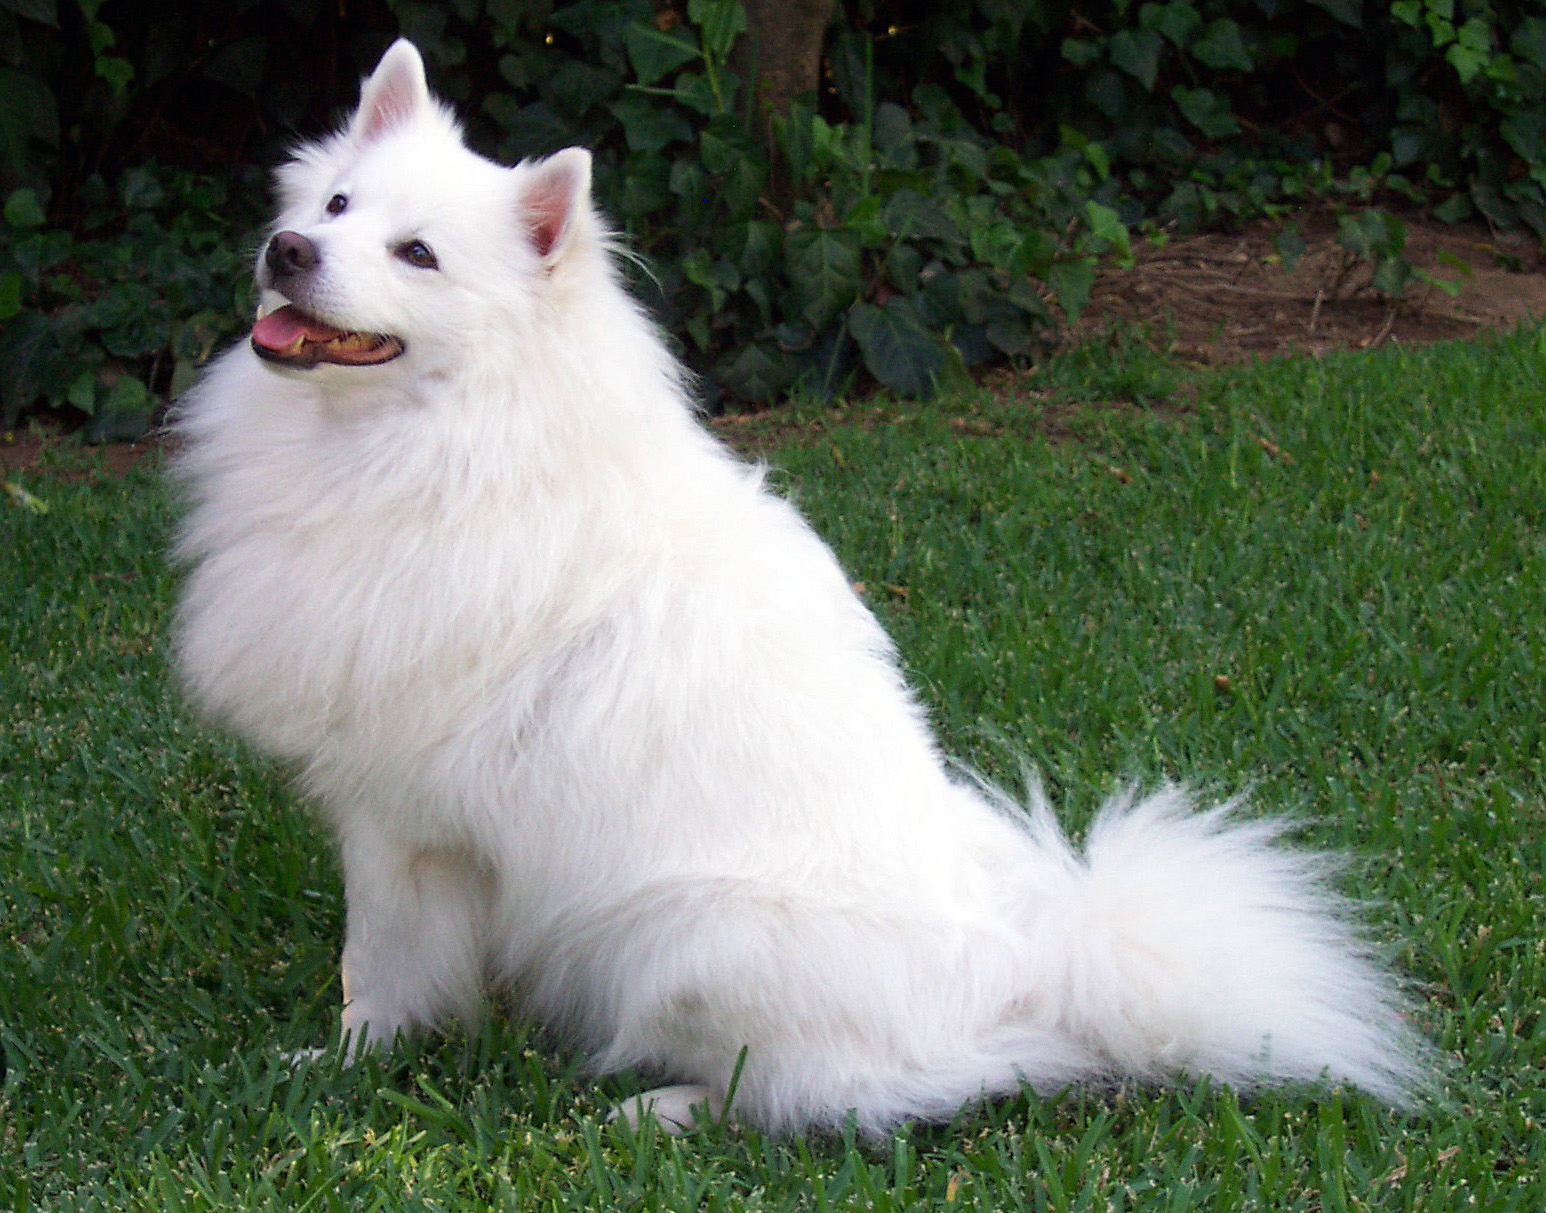

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
import urllib
url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
try: urllib.URLopener().retrieve(url, filename)
except: urllib.request.urlretrieve(url, filename)
    
from PIL import Image
dog_image = Image.open(filename)
display(dog_image)

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
# Preprocess torch image
from torchvision import transforms
from PIL import Image

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)])
torch_img = Image.open("dog.jpg")
torch_img = preprocess(dog_image)
torch_img = torch.unsqueeze(torch_img, 0)

In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
torch_googlenet_re.eval()

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
torch_googlenet_re(torch_img)

(tensor([[ 6.9530e-01,  6.6342e-01, -8.6900e-01, -3.9207e-01, -5.5661e-01,
          -2.6113e-01, -6.4357e-02,  8.2138e-01,  1.6820e+00, -6.8782e-03,
          -1.0739e+00, -8.5117e-01, -9.1162e-01, -1.0144e+00,  5.0030e-01,
          -5.7510e-02, -8.9864e-01,  3.4907e-01, -1.6160e-01, -4.6331e-01,
          -5.5341e-01, -2.1932e-01, -6.7937e-01,  1.9530e-01, -1.5375e-01,
          -1.2034e+00,  2.2678e-01,  2.2328e-02, -2.6456e-01,  2.1935e+00,
          -1.4658e-01, -2.0740e-01, -6.0592e-01, -8.9518e-01, -8.7505e-01,
          -8.7304e-01, -5.2359e-01, -6.5681e-01, -2.3848e-01, -2.0488e-02,
           1.5670e-01, -8.3121e-01, -5.2199e-01, -7.5972e-01,  4.1764e-01,
          -9.1077e-01,  3.1987e-01, -2.0960e-01, -1.0568e+00,  4.0403e-01,
           1.1765e+00,  2.5076e-02, -1.4832e-01, -9.3341e-01,  2.3610e-01,
           3.9198e-01, -5.4573e-01, -1.1303e+00, -1.0271e-01, -8.3695e-02,
           4.0121e-01, -1.0011e+00, -3.3786e-01,  1.1158e-01,  1.6678e-01,
          -2.4380e-01,  3